# Student Engagement Classification — Model Training
### *Branch B · Facial Engagement Classification*

---

| Field | Details |
|-------|---------|
| **Project** | Non-Invasive Cognitive Load and Student Engagement Detection |
| **Author** | Yasini Mandara Karunanayake |
| **RGU ID** | 2313473 **IIT ID** 20221151 |
| **Models** | SVM (RBF Kernel) · XGBoost |

---

## Notebook Overview

This notebook implements **Stage 2 of Branch B** of the multimodal pipeline.
It trains and evaluates two classifiers on the HOG feature vectors exported by the preprocessing notebook.

| Step | Description |
|------|-------------|
| 1 | Install & import dependencies |
| 2 | Load preprocessed HOG arrays & scaler |
| 3 | SVM (RBF kernel) — train, evaluate, confusion matrix, ROC curves |
| 4 | XGBoost — train, evaluate, loss curve, feature importances |
| 5 | Model comparison (Table 5.2) |
| 6 | Per-class error analysis (normalised CMs, precision/recall/F1) |
| 7 | Save best model (`best_engagement_model.pkl`) |


---
## 1. Install and Import

Install any packages not available by default in the Colab environment, then import all required libraries.


In [ ]:
!pip install -q imbalanced-learn scikit-image xgboost
print('Dependencies ready')


Dependencies ready


In [ ]:
# Standard library
import os
import warnings
import joblib
from pathlib import Path
from collections import Counter

# Numerical computing and data handling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Scikit-learn: SVM classifier and evaluation metrics
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score,
    f1_score, roc_auc_score, roc_curve
)
from sklearn.preprocessing import label_binarize

# XGBoost gradient boosting classifier
import xgboost as xgb

# Suppress warnings and fix random seed for reproducibility
warnings.filterwarnings('ignore')
np.random.seed(42)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
print('All imports successful')


All imports successful


## 2. Load Preprocessed Data

Load the HOG feature arrays and the fitted `StandardScaler` exported by the preprocessing notebook.
Two versions of the feature arrays are loaded because each classifier needs a different format:

| Array | Format | Used By |
|---|---|---|
| `X_train`, `X_test` | Raw, unscaled HOG | XGBoost (tree models are scale-invariant) |
| `X_train_sc`, `X_test_sc` | StandardScaler-normalised HOG | SVM (distance-sensitive; requires zero-mean, unit-variance input) |


In [ ]:
OUTPUT_DIR = Path('/content')

# Class labels in order low=0, medium=1, high=2
ENGAGEMENT_LABELS = ['low', 'medium', 'high']
LABEL_ENC = {lbl: i for i, lbl in enumerate(ENGAGEMENT_LABELS)}
LABEL_DEC = {i: lbl for lbl, i in LABEL_ENC.items()}
PALETTE   = {'low': '#e74c3c', 'medium': '#f39c12', 'high': '#2ecc71'}
RANDOM_STATE = 42

# Load raw HOG features for XGBoost (tree models do not need scaling)
X_train     = np.load(OUTPUT_DIR / 'X_train_hog.npy')
y_train     = np.load(OUTPUT_DIR / 'y_train.npy')
X_test      = np.load(OUTPUT_DIR / 'X_test_hog.npy')
y_test      = np.load(OUTPUT_DIR / 'y_test.npy')

# Load scaled HOG features for SVM (requires zero-mean, unit-variance input)
X_train_sc  = np.load(OUTPUT_DIR / 'X_train_hog_scaled.npy')
X_test_sc   = np.load(OUTPUT_DIR / 'X_test_hog_scaled.npy')

# Load the fitted scaler so it can be applied to new inputs at inference time
scaler      = joblib.load(OUTPUT_DIR / 'hog_scaler.pkl')

print(f'X_train (raw)    : {X_train.shape}    y_train : {y_train.shape}')
print(f'X_test  (raw)    : {X_test.shape}     y_test  : {y_test.shape}')
print(f'X_train (scaled) : {X_train_sc.shape}')
print(f'X_test  (scaled) : {X_test_sc.shape}')
print()
print('Train label distribution (post-SMOTE):')
for lbl, cnt in sorted(Counter(y_train).items()):
    print(f'  {LABEL_DEC[lbl]:8s} : {cnt}')
print('\nTest label distribution (original):')
for lbl, cnt in sorted(Counter(y_test).items()):
    print(f'  {LABEL_DEC[lbl]:8s} : {cnt}')


X_train (raw)    : (1878, 1764)    y_train : (1878,)
X_test  (raw)    : (450, 1764)     y_test  : (450,)
X_train (scaled) : (1878, 1764)
X_test  (scaled) : (450, 1764)

Train label distribution (post-SMOTE):
  low      : 626
  medium   : 626
  high     : 626

Test label distribution (original):
  low      : 90
  medium   : 270
  high     : 90


## 3. Model 1: SVM (RBF Kernel) + HOG

SVM with an RBF kernel is the first candidate for facial engagement classification.
Its margin-maximising objective is well-suited to the 1,764-dimensional HOG feature space relative to the number of training samples (~1,700 images).

**Key hyperparameter choices:**
| Parameter | Value | Reason |
|---|---|---|
| `C` | 10.0 | Allows moderate misclassification for a smoother decision boundary |
| `gamma` | `scale` | Auto-scales to `1 / (n_features x X.var())` — no manual tuning needed |
| `probability` | `True` | Enables Platt scaling so `predict_proba` is available for the fusion layer |
| `class_weight` | `balanced` | Guards against any residual class imbalance after SMOTE |


### 3.1 Train the SVM Classifier


In [ ]:
print('Training SVM (RBF kernel) on scaled HOG features …')
print(f'Training samples : {X_train_sc.shape[0]:,}  |  Features : {X_train_sc.shape[1]}')

svm = SVC(
    kernel='rbf',
    C=10.0,
    gamma='scale',
    decision_function_shape='ovr',
    probability=True,          # enables predict_proba output needed for the late fusion layer
    class_weight='balanced',   # adjusts weights inversely proportional to class frequency
    random_state=RANDOM_STATE
)
svm.fit(X_train_sc, y_train)
print('SVM training complete')


Training SVM (RBF kernel) on scaled HOG features …
Training samples : 1,878  |  Features : 1764
SVM training complete


### 3.2 Evaluate SVM on the Held-Out Test Set

Generate hard class predictions and soft probability outputs, then compute the three evaluation metrics used consistently throughout this research: Accuracy, Macro F1, and Macro ROC-AUC.


In [ ]:
# Predict class labels for each test sample
y_pred_svm  = svm.predict(X_test_sc)
# Predict class probabilities — needed for ROC-AUC and the late fusion layer
y_prob_svm  = svm.predict_proba(X_test_sc)

svm_acc = accuracy_score(y_test, y_pred_svm)
svm_f1  = f1_score(y_test, y_pred_svm, average='macro')

# Binarise test labels for one-vs-rest ROC-AUC computation
y_test_bin  = label_binarize(y_test, classes=[0, 1, 2])
svm_auc     = roc_auc_score(y_test_bin, y_prob_svm, multi_class='ovr', average='macro')

print('=' * 56)
print('  SVM + HOG — Classification Report')
print('=' * 56)
print(classification_report(
    y_test, y_pred_svm,
    target_names=[l.capitalize() for l in ENGAGEMENT_LABELS]
))
print(f'  Accuracy  : {svm_acc:.4f}')
print(f'  Macro F1  : {svm_f1:.4f}')
print(f'  Macro AUC : {svm_auc:.4f}')


  SVM + HOG — Classification Report
              precision    recall  f1-score   support

         Low       0.66      0.99      0.79        90
      Medium       1.00      0.83      0.91       270
        High       1.00      1.00      1.00        90

    accuracy                           0.90       450
   macro avg       0.88      0.94      0.90       450
weighted avg       0.93      0.90      0.90       450

  Accuracy  : 0.8956
  Macro F1  : 0.8987
  Macro AUC : 0.9506


### 3.3 Confusion Matrix

Each row represents the true class; each column represents the predicted class. Diagonal cells show correct predictions; off-diagonal cells show misclassifications.


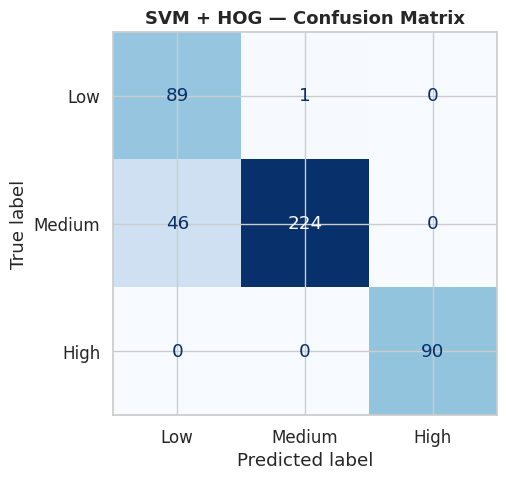

In [ ]:
# Build and display the SVM confusion matrix on the held-out test set
fig, ax = plt.subplots(figsize=(6, 5))
cm_svm = confusion_matrix(y_test, y_pred_svm)
ConfusionMatrixDisplay(
    cm_svm,
    display_labels=[l.capitalize() for l in ENGAGEMENT_LABELS]
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('SVM + HOG — Confusion Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cm_svm.png', dpi=150)
plt.show()


### 3.4 Per-Class ROC Curves

One-versus-rest ROC curves are plotted for each engagement class. The area under each curve (AUC) measures how well the model separates that class from the other two. An AUC of 1.0 is perfect; 0.5 is no better than random.


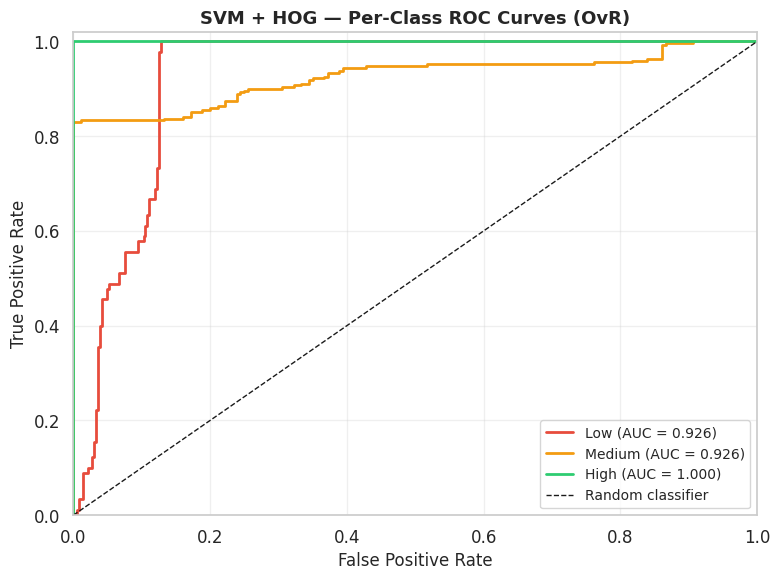

In [ ]:
# Plot one ROC curve per engagement class using the one-vs-rest strategy
fig, ax = plt.subplots(figsize=(8, 6))
colors = [PALETTE[l] for l in ENGAGEMENT_LABELS]

for i, (label, color) in enumerate(zip(ENGAGEMENT_LABELS, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_svm[:, i])
    auc_i = roc_auc_score(y_test_bin[:, i], y_prob_svm[:, i])
    ax.plot(fpr, tpr, lw=2, color=color,
            label=f'{label.capitalize()} (AUC = {auc_i:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('SVM + HOG — Per-Class ROC Curves (OvR)', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_svm.png', dpi=150)
plt.show()



## 4. Model 2: XGBoost + HOG

XGBoost is the second model. Gradient boosting on HOG features captures non-linear feature interactions that SVM's kernel may miss, and provides feature importance scores as an interpretability mechanism.
XGBoost is scale-invariant by construction, so the raw unscaled HOG features are used directly.

**Key hyperparameter choices:**
| Parameter | Value | Reason |
|---|---|---|
| `n_estimators` | 400 | Sufficient trees for the 1,764-dimensional HOG feature space |
| `max_depth` | 6 | Moderate depth to prevent overfitting on ~1,700 training samples |
| `learning_rate` | 0.05 | Slow learning with more trees for better generalisation |
| `subsample` / `colsample_bytree` | 0.8 | Stochastic boosting reduces variance and improves generalisation |
| `reg_alpha` / `reg_lambda` | 0.1 / 1.0 | L1 and L2 regularisation to reduce overfitting on high-dimensional input |


### 4.1 Train the XGBoost Classifier


In [ ]:
print('Training XGBoost on raw HOG features …')
print(f'Training samples : {X_train.shape[0]:,}  |  Features : {X_train.shape[1]}')

xgb_clf = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,        # prevents splits on very few samples
    gamma=0.1,                 # minimum loss reduction for split
    reg_alpha=0.1,             # L1 regularisation
    reg_lambda=1.0,            # L2 regularisation
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

xgb_clf.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)
print('\n XGBoost training complete')

Training XGBoost on raw HOG features …
Training samples : 1,878  |  Features : 1764
[0]	validation_0-mlogloss:1.04204
[50]	validation_0-mlogloss:0.35815
[100]	validation_0-mlogloss:0.37400
[150]	validation_0-mlogloss:0.39818
[200]	validation_0-mlogloss:0.41832
[250]	validation_0-mlogloss:0.43060
[300]	validation_0-mlogloss:0.43992
[350]	validation_0-mlogloss:0.44451
[399]	validation_0-mlogloss:0.44800

 XGBoost training complete


### 4.2 Evaluate XGBoost on the Held-Out Test Set

Same three metrics as SVM (Accuracy, Macro F1, Macro ROC-AUC) are computed to enable a direct comparison.


In [ ]:
# Predict class labels and class probabilities on the test set
y_pred_xgb  = xgb_clf.predict(X_test)
y_prob_xgb  = xgb_clf.predict_proba(X_test)

xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_f1  = f1_score(y_test, y_pred_xgb, average='macro')
xgb_auc = roc_auc_score(y_test_bin, y_prob_xgb, multi_class='ovr', average='macro')

print('=' * 56)
print('  XGBoost + HOG — Classification Report')
print('=' * 56)
print(classification_report(
    y_test, y_pred_xgb,
    target_names=[l.capitalize() for l in ENGAGEMENT_LABELS]
))
print(f'  Accuracy  : {xgb_acc:.4f}')
print(f'  Macro F1  : {xgb_f1:.4f}')
print(f'  Macro AUC : {xgb_auc:.4f}')


  XGBoost + HOG — Classification Report
              precision    recall  f1-score   support

         Low       0.66      1.00      0.80        90
      Medium       1.00      0.83      0.91       270
        High       1.00      1.00      1.00        90

    accuracy                           0.90       450
   macro avg       0.89      0.94      0.90       450
weighted avg       0.93      0.90      0.90       450

  Accuracy  : 0.8978
  Macro F1  : 0.9011
  Macro AUC : 0.9685


### 4.3 Confusion Matrix

Orange colour scheme distinguishes the XGBoost matrix from the blue SVM matrix for easy visual comparison.


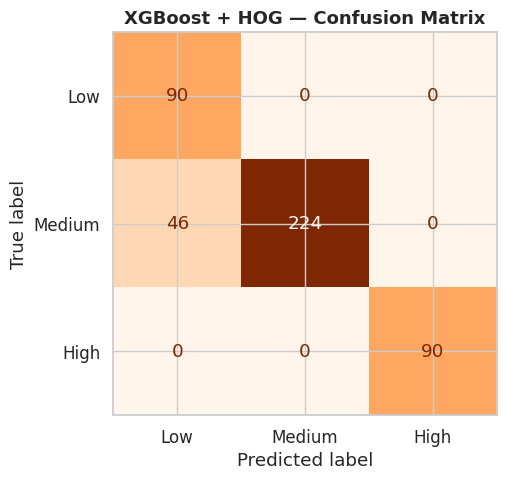

In [ ]:
# Build and display the XGBoost confusion matrix on the held-out test set
fig, ax = plt.subplots(figsize=(6, 5))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(
    cm_xgb,
    display_labels=[l.capitalize() for l in ENGAGEMENT_LABELS]
).plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('XGBoost + HOG — Confusion Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cm_xgb.png', dpi=150)
plt.show()


### 4.4 Validation Log-Loss Curve

The log-loss is recorded after every boosting round on the validation set. A steadily decreasing curve confirms the model is learning, and the round with the lowest loss indicates where the model converged.


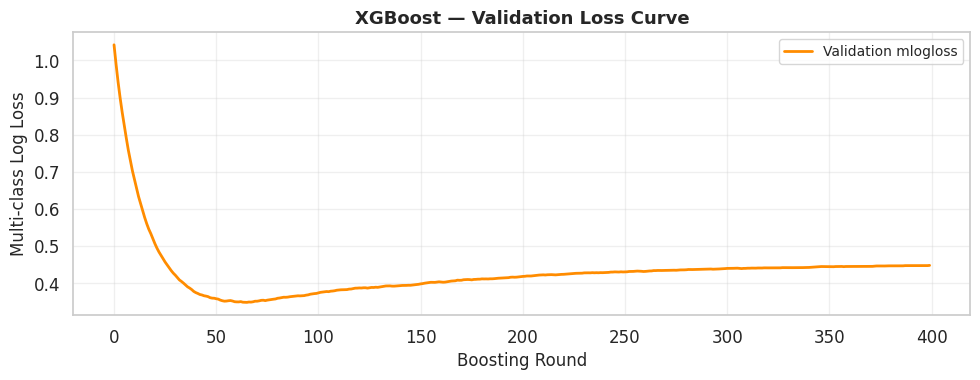

Best validation loss : 0.3484 at round 65


In [ ]:
# Retrieve per-round validation loss scores logged during training
evals      = xgb_clf.evals_result()
train_loss = evals.get('validation_0', {}).get('mlogloss', [])

if train_loss:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(train_loss, color='darkorange', linewidth=2, label='Validation mlogloss')
    ax.set_xlabel('Boosting Round', fontsize=12)
    ax.set_ylabel('Multi-class Log Loss', fontsize=12)
    ax.set_title('XGBoost — Validation Loss Curve', fontweight='bold', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'xgb_loss_curve.png', dpi=150)
    plt.show()
    print(f'Best validation loss : {min(train_loss):.4f} at round {train_loss.index(min(train_loss))}')


### 4.5 Per-Class ROC Curves

Same one-versus-rest approach as SVM. Plotting both models using the same axes in Section 5.4 will allow direct AUC comparison.


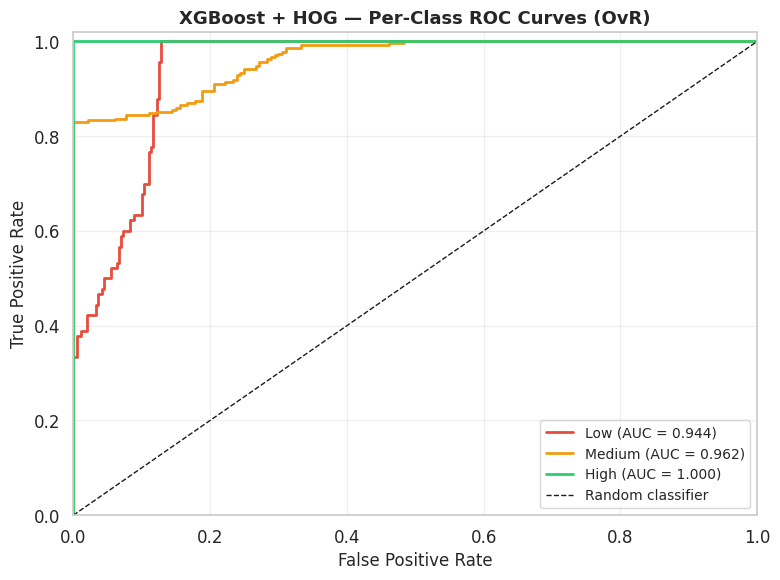

In [ ]:
# Plot one-vs-rest ROC curves for XGBoost across all three engagement classes
fig, ax = plt.subplots(figsize=(8, 6))

for i, (label, color) in enumerate(zip(ENGAGEMENT_LABELS, [PALETTE[l] for l in ENGAGEMENT_LABELS])):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_xgb[:, i])
    auc_i = roc_auc_score(y_test_bin[:, i], y_prob_xgb[:, i])
    ax.plot(fpr, tpr, lw=2, color=color,
            label=f'{label.capitalize()} (AUC = {auc_i:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('XGBoost + HOG — Per-Class ROC Curves (OvR)', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_xgb.png', dpi=150)
plt.show()


### 4.6 Top-25 HOG Feature Importances

XGBoost assigns an importance score to each HOG dimension based on how frequently it is used in split decisions. High-importance dimensions correspond to spatially informative gradient regions such as the periocular area and lower face.


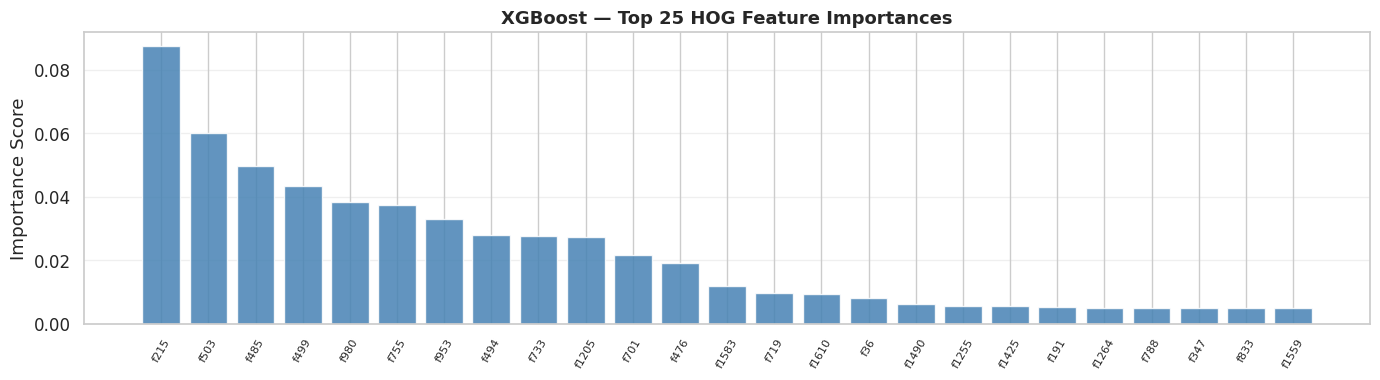

In [ ]:
# Extract importance scores for all 1,764 HOG dimensions
top_n       = 25
importances = xgb_clf.feature_importances_
# Sort in descending order and keep only the top 25 most important dimensions
top_idx     = np.argsort(importances)[::-1][:top_n]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(top_n), importances[top_idx],
       color='steelblue', alpha=0.85, edgecolor='white')
ax.set_xticks(range(top_n))
ax.set_xticklabels([f'f{i}' for i in top_idx], rotation=60, fontsize=8)
ax.set_title(f'XGBoost — Top {top_n} HOG Feature Importances',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Importance Score')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'xgb_feature_importance.png', dpi=150)
plt.show()


## 5. Model Comparison

Both classifiers are evaluated on the same held-out test set using Accuracy, Macro F1, and Macro ROC-AUC — the three metrics applied consistently throughout this research.
The model with the highest Macro F1 is selected as the **Branch B (SE) classifier** for the confidence-weighted late fusion layer.


### 5.1 Side-by-Side Confusion Matrices

Placing both confusion matrices next to each other makes it easy to compare where each model makes errors.


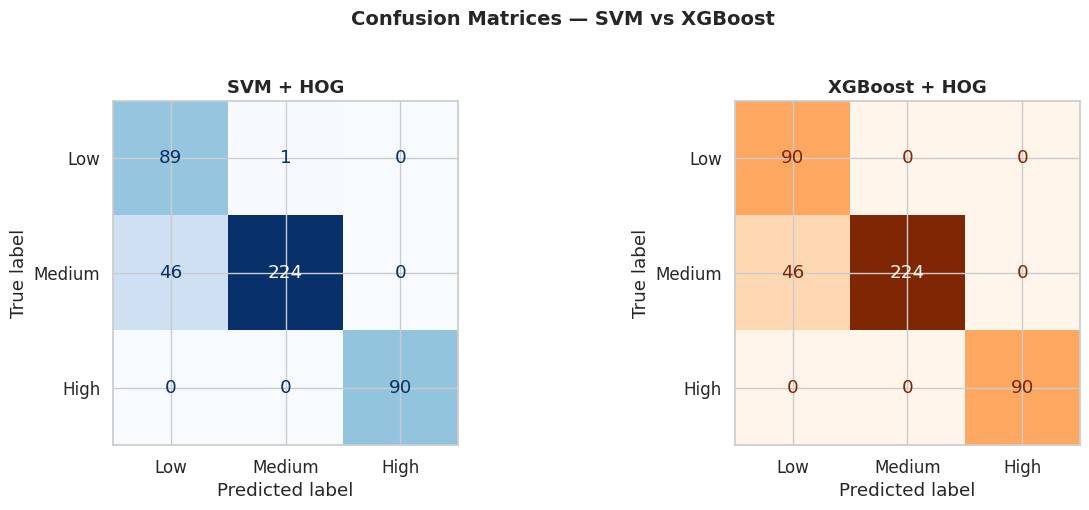

In [ ]:
disp_labels = [l.capitalize() for l in ENGAGEMENT_LABELS]
# Pair each confusion matrix with its model name and colour scheme
configs = [
    (cm_svm, 'SVM + HOG',     'Blues'),
    (cm_xgb, 'XGBoost + HOG', 'Oranges'),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (cm, title, cmap) in zip(axes, configs):
    ConfusionMatrixDisplay(cm, display_labels=disp_labels).plot(
        ax=ax, colorbar=False, cmap=cmap
    )
    ax.set_title(title, fontweight='bold', fontsize=13)

plt.suptitle('Confusion Matrices — SVM vs XGBoost',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.2 Performance Summary Table

Summarise accuracy, Macro F1, and Macro ROC-AUC for both models. The table is sorted by Macro F1 so the best model appears in the first row.


In [ ]:
# Build a results table comparing both models on all three evaluation metrics
results_df = pd.DataFrame([
    {
        'Model':    'SVM + HOG',
        'Accuracy': round(svm_acc, 4),
        'Macro F1': round(svm_f1,  4),
        'Macro AUC': round(svm_auc, 4),
        'Imbalance Strategy': 'SMOTE (train only)'
    },
    {
        'Model':    'XGBoost + HOG',
        'Accuracy': round(xgb_acc, 4),
        'Macro F1': round(xgb_f1,  4),
        'Macro AUC': round(xgb_auc, 4),
        'Imbalance Strategy': 'SMOTE (train only)'
    },
]).sort_values('Macro F1', ascending=False).reset_index(drop=True)

print('=' * 68)
print('  MODEL COMPARISON SUMMARY')
print('=' * 68)
print(results_df.to_string(index=False))
print('=' * 68)

best = results_df.iloc[0]
print(f"\n Best model : {best['Model']}  "
      f"(Accuracy={best['Accuracy']:.4f}, "
      f"Macro F1={best['Macro F1']:.4f}, "
      f"Macro AUC={best['Macro AUC']:.4f})")


  MODEL COMPARISON SUMMARY
        Model  Accuracy  Macro F1  Macro AUC Imbalance Strategy
XGBoost + HOG    0.8978    0.9011     0.9685 SMOTE (train only)
    SVM + HOG    0.8956    0.8987     0.9506 SMOTE (train only)

 Best model : XGBoost + HOG  (Accuracy=0.8978, Macro F1=0.9011, Macro AUC=0.9685)


### 5.3 Comparison Bar Chart

Grouped bar chart showing accuracy, Macro F1, and Macro AUC side by side for both models.


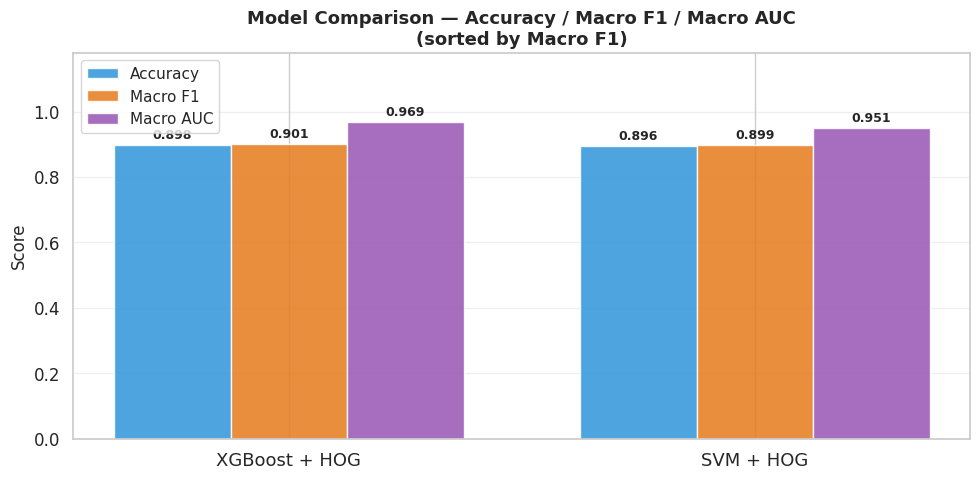

In [ ]:
# Extract metric scores as plain lists for matplotlib bar plotting
models    = results_df['Model'].tolist()
acc_vals  = results_df['Accuracy'].tolist()
f1_vals   = results_df['Macro F1'].tolist()
auc_vals  = results_df['Macro AUC'].tolist()

# x positions for each model; bars are offset by w so they sit side by side
x = np.arange(len(models))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w,   acc_vals, w, label='Accuracy',   color='#3498db', alpha=0.88)
b2 = ax.bar(x,       f1_vals,  w, label='Macro F1',   color='#e67e22', alpha=0.88)
b3 = ax.bar(x + w,   auc_vals, w, label='Macro AUC',  color='#9b59b6', alpha=0.88)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=13)
ax.set_ylim(0, 1.18)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — Accuracy / Macro F1 / Macro AUC\n(sorted by Macro F1)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Annotate each bar with its exact score value
for bar in list(b1) + list(b2) + list(b3):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison.png', dpi=150)
plt.show()


### 5.4 Overlay ROC Curves — SVM vs XGBoost

Both models are plotted on the same axes for each engagement class. This makes it easy to see which model achieves higher AUC per class.


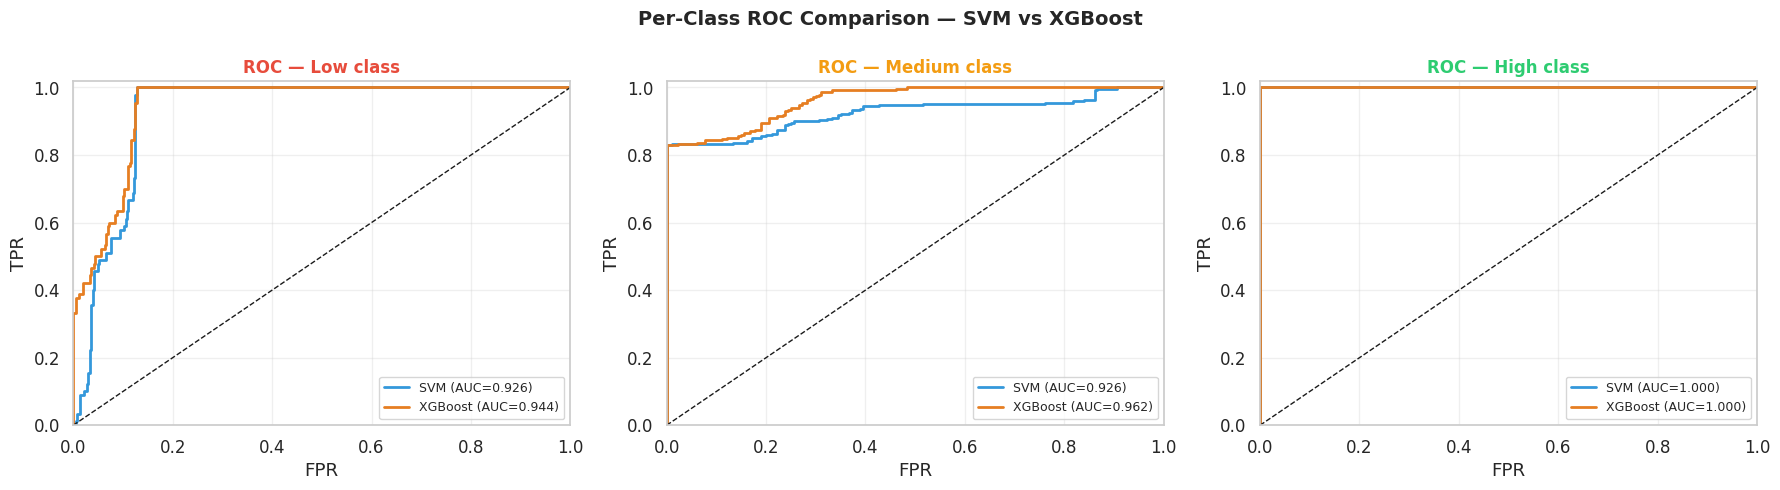

In [ ]:
# Three subplots, one per engagement class, comparing SVM and XGBoost AUC side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax_idx, (class_idx, label) in enumerate(zip([0, 1, 2], ENGAGEMENT_LABELS)):
    ax = axes[ax_idx]

    # SVM
    fpr_s, tpr_s, _ = roc_curve(y_test_bin[:, class_idx], y_prob_svm[:, class_idx])
    auc_s = roc_auc_score(y_test_bin[:, class_idx], y_prob_svm[:, class_idx])
    ax.plot(fpr_s, tpr_s, lw=2, color='#3498db',
            label=f'SVM (AUC={auc_s:.3f})')

    # XGBoost
    fpr_x, tpr_x, _ = roc_curve(y_test_bin[:, class_idx], y_prob_xgb[:, class_idx])
    auc_x = roc_auc_score(y_test_bin[:, class_idx], y_prob_xgb[:, class_idx])
    ax.plot(fpr_x, tpr_x, lw=2, color='#e67e22',
            label=f'XGBoost (AUC={auc_x:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_title(f'ROC — {label.capitalize()} class',
                 fontsize=12, fontweight='bold',
                 color=PALETTE[label])
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Per-Class ROC Comparison — SVM vs XGBoost',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
